In [17]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import os
import logging
import scipy

load = torch.load("Bayesian/hmc_posterior_predictive.pt")
load["samples"], load["x_val"], load["t_val"]

([tensor([ 0.1141, -0.1591,  0.1327,  ..., -0.0711,  0.0000,  0.0000])],
 tensor([[-5.0000],
         [-5.0000],
         [-5.0000],
         ...,
         [ 4.9609],
         [ 4.9609],
         [ 4.9609]]),
 tensor([[0.0000],
         [0.0079],
         [0.0157],
         ...,
         [1.5551],
         [1.5629],
         [1.5708]]))

In [23]:
os.makedirs("Data", exist_ok=True)
mat_path = "Data/NLS.mat"

data = scipy.io.loadmat(mat_path)
# Raw arrays from .mat
t_np = data['tt'].flatten()[:, None]   # shape [Nt, 1]
x_np = data['x'].flatten()[:, None]    # shape [Nx, 1]
Exact = data['uu']         
result = load["pred_mean"]
result_std = load["pred_std"]

In [24]:
T_np, X_np = np.meshgrid(t_np.flatten(), x_np.flatten())

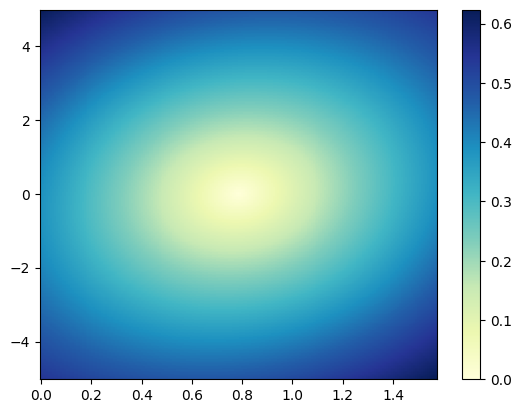

In [25]:
np_result = np.abs(result.detach().cpu().numpy()[:,1] * 1j + result.detach().cpu().numpy()[:,0])

plt.pcolormesh(T_np, X_np, np_result.reshape(T_np.shape[0], T_np.shape[1]), cmap="YlGnBu")
plt.colorbar()
plt.show()

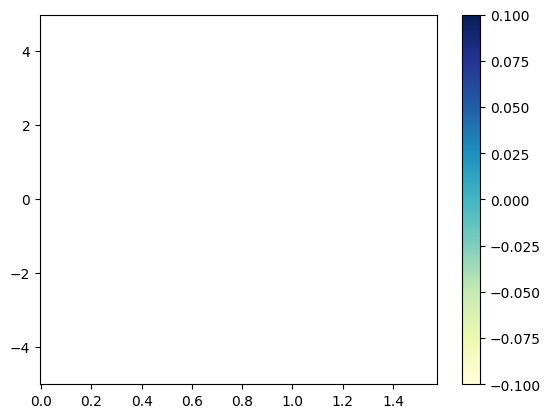

In [26]:
np_result = np.abs(result_std.detach().cpu().numpy()[:,1] * 1j + result_std.detach().cpu().numpy()[:,0])

plt.pcolormesh(T_np, X_np, np_result.reshape(T_np.shape[0], T_np.shape[1]), cmap="YlGnBu")
plt.colorbar()
plt.show()